# Product Experiment: Increasing Lead Conversion

This notebook simulates a product experiment designed to improve lead conversion in a marketplace-style funnel.

The analysis demonstrates:

- A/B testing
- Funnel analysis
- Segmentation
- Logistic regression
- CUPED variance reduction
- ML-based CUPAC adjustment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn

print("Environment ready 🚀")

Environment ready 🚀


In [2]:
print("Second run")

Second run


## Data Simulation

In [3]:
np.random.seed(42)

# ----------------------------
# Parameters
# ----------------------------
N_AGENTS = 2000

# ----------------------------
# Generate agent base info
# ----------------------------
agents = pd.DataFrame({
    "agent_id": np.arange(1, N_AGENTS + 1),
    "region": np.random.choice(
        ["West", "Midwest", "South", "Northeast"],
        size=N_AGENTS,
        p=[0.35, 0.25, 0.25, 0.15]
    ),
    "tenure_months": np.random.gamma(shape=2, scale=12, size=N_AGENTS).astype(int),
})

# Baseline conversion skill (some agents better than others)
agents["baseline_skill"] = np.clip(
    np.random.normal(loc=0.12, scale=0.03, size=N_AGENTS),
    0.05,
    0.25
)

# ----------------------------
# Randomized Experiment Assignment
# ----------------------------
agents["treatment"] = np.random.binomial(1, 0.5, N_AGENTS)

agents.head()

,agent_id,region,tenure_months,baseline_skill,treatment
0,1,Midwest,9,0.094607,0
1,2,Northeast,9,0.147770,1
2,3,South,37,0.110077,1
3,4,Midwest,9,0.104695,1
4,5,West,19,0.124484,0


In [4]:
# ----------------------------
# Parameters
# ----------------------------
N_LEADS = 100_000

# ----------------------------
# Generate leads
# ----------------------------

leads = pd.DataFrame({
    "lead_id": np.arange(1, N_LEADS + 1),
    
    # randomly assign leads to agents
    "agent_id": np.random.choice(agents["agent_id"], size=N_LEADS),
    
    # simulate lead quality score (0 to 1)
    "lead_quality": np.clip(
        np.random.beta(a=2, b=5, size=N_LEADS), 
        0.01, 
        0.99
    )
})

# simulate lead creation timestamps (over 60 days)
start_date = pd.Timestamp("2024-01-01")
leads["created_at"] = start_date + pd.to_timedelta(
    np.random.randint(0, 60*24*60, size=N_LEADS), 
    unit="m"
)

leads.head()

,lead_id,agent_id,lead_quality,created_at
0,1,1926,0.289826,2024-02-25 10:09:00
1,2,1097,0.111714,2024-01-09 02:02:00
2,3,1473,0.186623,2024-01-10 06:06:00
3,4,1100,0.401250,2024-01-21 06:25:00
4,5,698,0.524505,2024-01-16 03:34:00


In [5]:
leads.shape

(100000, 4)

In [6]:
leads["lead_quality"].describe()

count    100000.000000
mean          0.285329
std           0.159698
min           0.010000
25%           0.160633
50%           0.264370
75%           0.388911
max           0.934350
Name: lead_quality, dtype: float64

## Conversion Funnel

In [7]:
# ----------------------------
# Join leads with agent attributes
# ----------------------------
df = leads.merge(
    agents[["agent_id", "region", "tenure_months", "baseline_skill", "treatment"]],
    on="agent_id",
    how="left"
)

# ----------------------------
# Helper: logistic function
# ----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ----------------------------
# Response probability
#   - higher lead_quality => more likely to respond
#   - more tenure => slightly better
#   - treatment => faster/more consistent follow-up (small uplift)
# ----------------------------
x_resp = (
    -1.2
    + 2.4 * df["lead_quality"]
    + 0.003 * df["tenure_months"]
    + 0.35 * df["treatment"]
)
p_resp = sigmoid(x_resp)
df["responded"] = np.random.binomial(1, p_resp)

# ----------------------------
# Appointment probability (conditional on responded)
#   - depends on baseline_skill + lead_quality + treatment
# ----------------------------
x_appt = (
    -1.6
    + 2.0 * df["lead_quality"]
    + 3.0 * df["baseline_skill"]
    + 0.25 * df["treatment"]
)
p_appt = sigmoid(x_appt) * df["responded"]
df["set_appointment"] = np.random.binomial(1, p_appt)

# ----------------------------
# Close probability (conditional on appointment)
# ----------------------------
x_close = (
    -2.2
    + 1.6 * df["lead_quality"]
    + 2.5 * df["baseline_skill"]
    + 0.10 * df["treatment"]
)
p_close = sigmoid(x_close) * df["set_appointment"]
df["closed"] = np.random.binomial(1, p_close)

# ----------------------------
# Guardrail: unsubscribe probability (can increase with treatment)
#   - higher follow-up intensity may increase opt-out slightly
# ----------------------------
x_unsub = (
    -3.8
    + 0.9 * (1 - df["lead_quality"])   # lower-quality leads opt out more
    + 0.25 * df["treatment"]           # slight negative side effect
)
p_unsub = sigmoid(x_unsub)
df["unsubscribed"] = np.random.binomial(1, p_unsub)

df[["lead_id","agent_id","treatment","lead_quality","responded","set_appointment","closed","unsubscribed"]].head()

,lead_id,agent_id,treatment,lead_quality,responded,set_appointment,closed,unsubscribed
0,1,1926,0,0.289826,1,0,0,0
1,2,1097,1,0.111714,0,0,0,1
2,3,1473,0,0.186623,0,0,0,0
3,4,1100,1,0.401250,0,0,0,0
4,5,698,0,0.524505,1,0,0,0


In [8]:
summary = df.groupby("treatment")[["responded","set_appointment","closed","unsubscribed"]].mean()
summary

,responded,set_appointment,closed,unsubscribed
treatment,,,,
0,0.396220,0.142081,0.030349,0.042951
1,0.475208,0.196560,0.045694,0.051658


## A/B Test Results

In [9]:
from scipy import stats

def ab_test(df, metric):
    control = df[df["treatment"] == 0][metric]
    treat = df[df["treatment"] == 1][metric]
    
    stat, pval = stats.ttest_ind(treat, control)
    
    uplift = treat.mean() - control.mean()
    
    return {
        "metric": metric,
        "control_mean": control.mean(),
        "treatment_mean": treat.mean(),
        "uplift": uplift,
        "p_value": pval
    }

results = pd.DataFrame([
    ab_test(df, "responded"),
    ab_test(df, "set_appointment"),
    ab_test(df, "closed"),
    ab_test(df, "unsubscribed"),
])

results

,metric,control_mean,treatment_mean,uplift,p_value
0,responded,0.396220,0.475208,0.078988,2.315821e-140
1,set_appointment,0.142081,0.196560,0.054479,7.852641e-117
2,closed,0.030349,0.045694,0.015345,8.169669e-37
3,unsubscribed,0.042951,0.051658,0.008707,9.078571e-11


## Funnel Analysis

In [10]:
# Calculate funnel rates
funnel = df.groupby("treatment")[["responded","set_appointment","closed"]].mean().reset_index()

funnel

,treatment,responded,set_appointment,closed
0,0,0.396220,0.142081,0.030349
1,1,0.475208,0.196560,0.045694


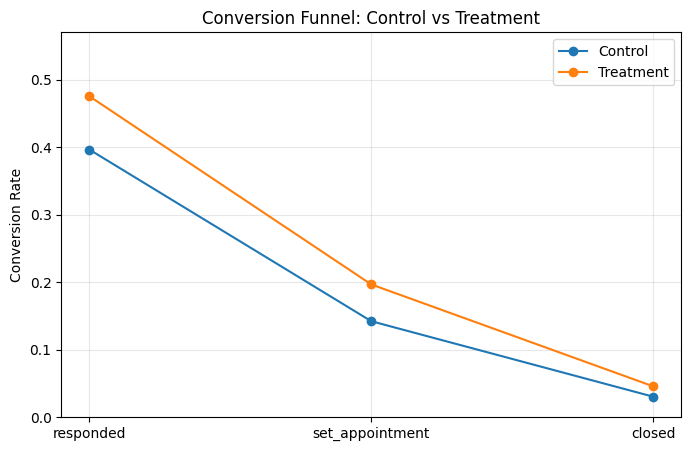

In [11]:
import matplotlib.pyplot as plt

stages = ["responded", "set_appointment", "closed"]

control_rates = funnel[funnel["treatment"] == 0][stages].values.flatten()
treatment_rates = funnel[funnel["treatment"] == 1][stages].values.flatten()

plt.figure(figsize=(8,5))

plt.plot(stages, control_rates, marker="o", label="Control")
plt.plot(stages, treatment_rates, marker="o", label="Treatment")

plt.title("Conversion Funnel: Control vs Treatment")
plt.ylabel("Conversion Rate")
plt.ylim(0, max(treatment_rates)*1.2)
plt.legend()

plt.grid(alpha=0.3)
plt.show()

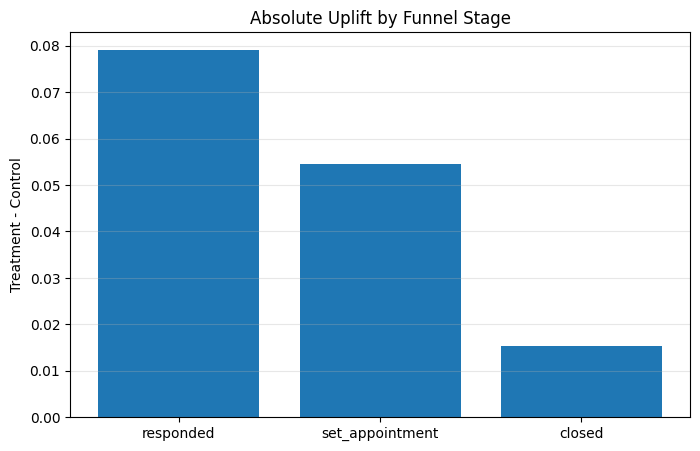

In [12]:
uplift = treatment_rates - control_rates

plt.figure(figsize=(8,5))
plt.bar(stages, uplift)

plt.title("Absolute Uplift by Funnel Stage")
plt.ylabel("Treatment - Control")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Segmentation by Lead Quality

In [13]:
# Create quality buckets
df["quality_bucket"] = pd.qcut(
    df["lead_quality"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["lead_quality", "quality_bucket"]].head()

,lead_quality,quality_bucket
0,0.289826,Medium
1,0.111714,Low
2,0.186623,Low
3,0.401250,High
4,0.524505,High


In [14]:
seg_summary = (
    df.groupby(["quality_bucket", "treatment"])["closed"]
    .mean()
    .unstack()
)

seg_summary["uplift"] = seg_summary[1] - seg_summary[0]

seg_summary

treatment,0,1,uplift
quality_bucket,,,
Low,0.012166,0.020936,0.008770
Medium,0.022875,0.035748,0.012873
High,0.056155,0.080203,0.024048


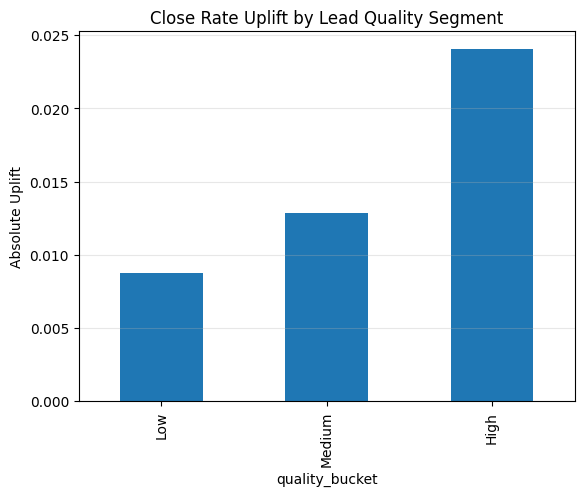

In [15]:
seg_summary["uplift"].plot(kind="bar")

plt.title("Close Rate Uplift by Lead Quality Segment")
plt.ylabel("Absolute Uplift")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Regression Analysis

In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Convert treatment to int（it already is though）
df["treatment"] = df["treatment"].astype(int)

# Logistic regression with interaction
model = smf.logit(
    formula="closed ~ treatment + lead_quality + treatment:lead_quality",
    data=df
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.152618
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 closed   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99996
Method:                           MLE   Df Model:                            3
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                 0.05747
Time:                        06:12:36   Log-Likelihood:                -15262.
converged:                       True   LL-Null:                       -16192.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4.8566      0.065    -75.079      0.000      -4.983      -4.730
treatment                  0.5351      0.083      6.469      0.000       0.373       0.697
lead_quality               4.1183      0.150     27.479      0.000       3.825       4.412
treatment:lead_quality    -0.2761      0.193     -1.428      0.153      -0.655       0.103
==========================================================================================
"""

In [18]:
df.head(10)

,lead_id,agent_id,lead_quality,created_at,region,tenure_months,baseline_skill,treatment,responded,set_appointment,closed,unsubscribed,quality_bucket
0,1,1926,0.289826,2024-02-25 10:09:00,West,5,0.118662,0,1,0,0,0,Medium
1,2,1097,0.111714,2024-01-09 02:02:00,West,10,0.084273,1,0,0,0,1,Low
2,3,1473,0.186623,2024-01-10 06:06:00,Northeast,32,0.127226,0,0,0,0,0,Low
3,4,1100,0.401250,2024-01-21 06:25:00,Midwest,23,0.085979,1,0,0,0,0,High
4,5,698,0.524505,2024-01-16 03:34:00,Midwest,59,0.150202,0,1,0,0,0,High
5,6,590,0.106850,2024-01-13 16:54:00,West,32,0.178267,0,0,0,0,1,Low
6,7,390,0.138738,2024-02-12 20:30:00,South,3,0.050000,0,1,0,0,0,Low
7,8,1601,0.563958,2024-02-26 10:24:00,West,19,0.111536,0,1,0,0,0,High
8,9,1366,0.227487,2024-02-29 17:44:00,West,28,0.164148,0,0,0,0,0,Medium
9,10,1314,0.597028,2024-02-03 17:11:00,South,42,0.146469,0,0,0,0,0,High


In [19]:
import numpy as np
import pandas as pd

params = model.params
conf = model.conf_int()
conf.columns = ["ci_lower", "ci_upper"]

or_table = pd.DataFrame({
    "coef": params,
    "odds_ratio": np.exp(params),
    "or_ci_lower": np.exp(conf["ci_lower"]),
    "or_ci_upper": np.exp(conf["ci_upper"]),
    "p_value": model.pvalues
})

or_table.loc[["treatment", "lead_quality", "treatment:lead_quality"]]

,coef,odds_ratio,or_ci_lower,or_ci_upper,p_value
treatment,0.535123,1.707658,1.452076,2.008225,9.860448e-11
lead_quality,4.118275,61.453132,45.811695,82.435009,3.095912e-166
treatment:lead_quality,-0.276134,0.758712,0.519341,1.108411,1.533586e-01


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["responded", "set_appointment", "closed", "unsubscribed"]

rows = []
for m in metrics:
    c = df[df["treatment"] == 0][m]
    t = df[df["treatment"] == 1][m]
    p0, p1 = c.mean(), t.mean()
    n0, n1 = c.shape[0], t.shape[0]

    diff = p1 - p0
    se = np.sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
    ci_low = diff - 1.96*se
    ci_high = diff + 1.96*se

    rows.append([m, p0, p1, diff, ci_low, ci_high])

uplift_ci = pd.DataFrame(rows, columns=["metric","control","treatment","uplift","ci_low","ci_high"])
uplift_ci

,metric,control,treatment,uplift,ci_low,ci_high
0,responded,0.396220,0.475208,0.078988,0.072862,0.085115
1,set_appointment,0.142081,0.196560,0.054479,0.049845,0.059112
2,closed,0.030349,0.045694,0.015345,0.012979,0.017711
3,unsubscribed,0.042951,0.051658,0.008707,0.006077,0.011337


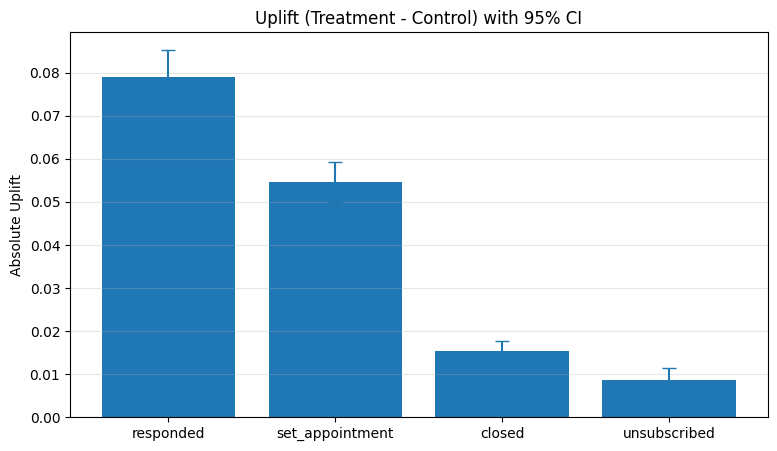

In [21]:
# Plot
plt.figure(figsize=(9,5))

x = np.arange(len(uplift_ci))
y = uplift_ci["uplift"].values
yerr = np.vstack([y - uplift_ci["ci_low"].values, uplift_ci["ci_high"].values - y])

plt.bar(uplift_ci["metric"], y)
plt.errorbar(uplift_ci["metric"], y, yerr=yerr, fmt="none", capsize=5)

plt.title("Uplift (Treatment - Control) with 95% CI")
plt.ylabel("Absolute Uplift")
plt.grid(axis="y", alpha=0.3)
plt.show()

## CUPED Variance Reduction

In [22]:
import numpy as np
from scipy import stats

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 1) Create a “pre-treatment covariate” X：prior propensity（without treatment）
#   Note: X is only determined by lead_quality + baseline_skill，to mimick pre-period propensity
X = sigmoid(-2.2 + 1.6*df["lead_quality"] + 2.5*df["baseline_skill"])

# 2) Original outcome
Y = df["closed"].astype(float)

# 3) CUPED theta = Cov(Y, X) / Var(X)
theta = np.cov(Y, X, ddof=1)[0,1] / np.var(X, ddof=1)

# 4) Adjusted outcome
Y_adj = Y - theta*(X - X.mean())
df["closed_cuped"] = Y_adj

theta

np.float64(0.6236039105054322)

In [23]:
# Compare uplift before/after CUPED
def ab_summary(metric_col):
    c = df[df["treatment"] == 0][metric_col]
    t = df[df["treatment"] == 1][metric_col]
    uplift = t.mean() - c.mean()
    stat, pval = stats.ttest_ind(t, c, equal_var=False)
    return c.mean(), t.mean(), uplift, pval

raw = ab_summary("closed")
cuped = ab_summary("closed_cuped")

pd.DataFrame(
    [raw, cuped],
    columns=["control_mean","treatment_mean","uplift","p_value"],
    index=["Raw closed", "CUPED-adjusted closed"]
)

,control_mean,treatment_mean,uplift,p_value
Raw closed,0.030349,0.045694,0.015345,5.470461e-37
CUPED-adjusted closed,0.030257,0.045784,0.015528,1.473577e-38


In [24]:
# ----------------------------
# Simulate PRE-period close (before treatment)
# ----------------------------

# Create pre-period log-odds（without treatment）
x_pre = (
    -2.2
    + 1.6 * df["lead_quality"]
    + 2.5 * df["baseline_skill"]
)

p_pre = 1 / (1 + np.exp(-x_pre))

df["pre_closed"] = np.random.binomial(1, p_pre)

df[["pre_closed", "closed"]].head()

,pre_closed,closed
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [25]:
df[["pre_closed", "closed"]].corr()

,pre_closed,closed
pre_closed,1.000000,0.017846
closed,0.017846,1.000000


In [26]:
np.var(df["closed"]), np.var(df["closed_cuped"])

(np.float64(0.03666686559999999), np.float64(0.03594299103062175))

In [27]:
df[df["responded"] == 0]["set_appointment"].sum()

np.int64(0)

In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Features must be pre-treatment only (no treatment column!)
feature_cols_num = ["lead_quality", "baseline_skill", "tenure_months", "pre_closed"]
feature_cols_cat = ["region"]

X = df[feature_cols_num + feature_cols_cat].copy()
y = df["closed"].astype(int).values

# Preprocess: one-hot encode region
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
        ("num", "passthrough", feature_cols_num),
    ]
)

# A simple, stable model (good enough + easy to explain)
model = Pipeline(
    steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=1000))
    ]
)

# Cross-fitting: out-of-fold predicted probabilities
kf = KFold(n_splits=5, shuffle=True, random_state=42)
yhat = np.zeros(len(df), dtype=float)

for train_idx, test_idx in kf.split(X):
    model.fit(X.iloc[train_idx], y[train_idx])
    yhat[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]

df["yhat_cupac"] = yhat

df[["closed", "yhat_cupac", "treatment"]].head()

,closed,yhat_cupac,treatment
0,0,0.029599,0
1,0,0.014412,1
2,0,0.022792,0
3,0,0.044459,1
4,0,0.086102,0


In [29]:
from scipy import stats

Y = df["closed"].astype(float).values
Xhat = df["yhat_cupac"].astype(float).values

theta = np.cov(Y, Xhat, ddof=1)[0, 1] / np.var(Xhat, ddof=1)
Y_cupac = Y - theta * (Xhat - Xhat.mean())

df["closed_cupac"] = Y_cupac

theta

np.float64(0.9844705768043461)

In [31]:
def ab_test(col):
    c = df[df["treatment"] == 0][col].astype(float).values
    t = df[df["treatment"] == 1][col].astype(float).values
    uplift = t.mean() - c.mean()
    stat, pval = stats.ttest_ind(t, c, equal_var=False)
    return c.mean(), t.mean(), uplift, pval, np.var(np.r_[c, t], ddof=1)

out = []

# Raw
c0, t0, u0, p0, v0 = ab_test("closed")
out.append(["Raw (closed)", c0, t0, u0, p0, v0])

# CUPED with pre_closed (the classic one you built)
# (Assumes you've already created df["closed_cuped"] from pre_closed)
if "closed_cuped" in df.columns:
    c1, t1, u1, p1, v1 = ab_test("closed_cuped")
    out.append(["CUPED (pre_closed)", c1, t1, u1, p1, v1])

# CUPAC
c2, t2, u2, p2, v2 = ab_test("closed_cupac")
out.append(["CUPAC (ML yhat)", c2, t2, u2, p2, v2])

pd.DataFrame(out, columns=["method","control_mean","treatment_mean","uplift","p_value","pooled_variance"])

,method,control_mean,treatment_mean,uplift,p_value,pooled_variance
0,Raw (closed),0.030349,0.045694,0.015345,5.470461e-37,0.036667
1,CUPED (pre_closed),0.030257,0.045784,0.015528,1.473577e-38,0.035943
2,CUPAC (ML yhat),0.030373,0.045671,0.015297,1.680711e-37,0.035916


## Key Takeaways

The Smart Reminder treatment increases early-stage engagement and improves downstream conversion.

Variance reduction techniques such as CUPED and CUPAC reduce estimator variance while preserving unbiased treatment effect estimates.

These methods are commonly used in modern experimentation platforms to increase experiment sensitivity.